# Isolated Rerank Agent Evaluation

This notebook evaluates `src/agents/rerank.py` in isolation on the first 20 queries of the MS MARCO dev2 topic file.

For each query:
1. Retrieve top-50 documents with the original query (the **initial retrieval**).
2. Pass the initial ranking to the `RerankingAgent`, which uses a cross-encoder to re-score the top documents.
3. Compute NDCG@10 for both the initial ranking and the reranked ranking using the dev2 qrels.

Queries are then grouped by whether reranking **helped**, left **unchanged**, or **harmed** NDCG@10.  Statistics are reported for the *initially retrieved* documents of each group.

**Abbreviations used throughout**
- `NDCG`: Normalized Discounted Cumulative Gain, a ranking quality metric (1 = perfect, 0 = none).
- `TF`: Term Frequency – how often a query term occurs in the retrieved corpus.
- `DF`: Document Frequency – in how many of the retrieved documents a query term appears.
- `df_cv`: Coefficient of variation of DF values (`std / mean`). Higher values mean the query terms are more unevenly distributed across the initial documents (more dispersion).
- `niche_term_ratio`: Fraction of query terms that appear in at most 1 initial document.
- `RR`: Reciprocal Rank, `1 / rank_of_first_relevant_document`.
- `top_k_rerank`: Number of top documents the cross-encoder re-scores.

In [1]:
# -----------------------------------------------------------------------------
# CELL 1: Configuration
# -----------------------------------------------------------------------------
from pathlib import Path

ROOT = Path.cwd().parent

TOPICS_PATH = ROOT / "notebooks" / "queries" / "topics.ms-marco-dev2.tsv"
QRELS_PATH = ROOT / "notebooks" / "qrels" / "qrels.ms-marco-dev2.tsv"
OUTPUT_CSV = ROOT / "notebooks" / "rerank_isolated_results.csv"

TOP_K = 50              # Number of documents retrieved per query.
NDCG_K = 10             # Cut-off used for NDCG and for grouping queries.
NUM_QUERIES = 20        # First N queries from the topics file.
TOP_K_RERANK = 50       # How many of the top initial documents the reranker re-scores.

DELTA_EPS = 1e-4        # Threshold for deciding whether NDCG changed.
NICHE_DF_THRESHOLD = 1  # DF threshold used to define niche query terms.

## Imports and environment setup

In [2]:
# -----------------------------------------------------------------------------
# CELL 2: Imports
# -----------------------------------------------------------------------------
import re
import sys
import warnings
from collections import Counter, defaultdict
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
from dotenv import load_dotenv

from urllib3.exceptions import InsecureRequestWarning
warnings.simplefilter("ignore", InsecureRequestWarning)

sys.path.insert(0, str(ROOT / "src"))

from sentence_transformers import SentenceTransformer
from src.agents.rerank import RerankingAgent
from src.utils.retriever import Retriever, create_retriever_callable

load_dotenv()

c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Load queries and qrels

In [3]:
# -----------------------------------------------------------------------------
# CELL 3: Load queries and qrels
# -----------------------------------------------------------------------------
def load_queries(path: Path, n: int) -> List[Tuple[str, str]]:
    queries = []
    with path.open("r", encoding="utf-8") as f:
        next(f)  # skip header
        for i, line in enumerate(f):
            if i >= n:
                break
            qid, qtext = line.strip().split("\t", 1)
            queries.append((qid, qtext))
    return queries


def load_qrels(path: Path) -> Dict[str, Dict[str, int]]:
    """Load qrels as {query_id: {doc_id: relevance}}."""
    qrels = defaultdict(dict)
    with path.open("r", encoding="utf-8") as f:
        next(f)
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) < 4:
                continue
            qid, _, doc_id, rel = parts[0], parts[1], parts[2], parts[3]
            qrels[qid][doc_id] = int(rel)
    return qrels


queries = load_queries(TOPICS_PATH, NUM_QUERIES)
qrels = load_qrels(QRELS_PATH)
print(f"Loaded {len(queries)} queries and {sum(len(v) for v in qrels.values())} qrel entries.")

Loaded 20 queries and 5177 qrel entries.


## Helper functions

In [4]:
# -----------------------------------------------------------------------------
# CELL 4: NDCG and corpus-statistics helpers
# -----------------------------------------------------------------------------
def normalize_doc_id(doc_id: str) -> str:
    """Strip passage-level suffix (#...) to match qrel document identifiers."""
    return doc_id.split("#")[0] if "#" in doc_id else doc_id


def compute_dcg(relevances: List[int], k: int) -> float:
    """DCG@k with the standard (2^rel - 1) / log2(rank + 1) formulation."""
    dcg = 0.0
    for i, rel in enumerate(relevances[:k]):
        if rel > 0:
            dcg += (2 ** rel - 1) / np.log2(i + 2)
    return dcg


def deduplicate_relevance(doc_ids: List[str], graded: List[int]) -> List[int]:
    """
    Deduplicate passage-level retrieval results to document-level relevance.
    The first occurrence of a normalized document keeps its relevance; later
    duplicates are treated as non-relevant (0).
    """
    seen = set()
    dedup = []
    for did, rel in zip(doc_ids, graded):
        norm = normalize_doc_id(did)
        if norm not in seen:
            dedup.append(rel)
            seen.add(norm)
        else:
            dedup.append(0)
    return dedup


def compute_ndcg(doc_ids: List[str], qid: str, k: int) -> float:
    """Compute NDCG@k for a ranked list of document IDs."""
    graded = [qrels[qid].get(normalize_doc_id(d), 0) for d in doc_ids]
    graded = deduplicate_relevance(doc_ids, graded)
    dcg = compute_dcg(graded, k)

    ideal = sorted(qrels[qid].values(), reverse=True)
    ideal = ideal + [0] * (k - len(ideal))
    idcg = compute_dcg(ideal, k)

    return dcg / idcg if idcg > 0 else 0.0


def tokenize(text: str) -> List[str]:
    """Simple regex tokenizer: lowercase, keep alphanumeric tokens."""
    return re.findall(r"\b[a-z0-9]+\b", text.lower())


def compute_initial_corpus_stats(query_text: str, doc_texts: List[str]) -> Dict[str, float]:
    """
    Compute corpus statistics for the initially retrieved (baseline) documents.
    
    Returns:
      - query_length_terms: number of unique query terms
      - num_docs: number of retrieved documents
      - coverage: fraction of query terms that appear anywhere in the corpus
      - mean_tf / median_tf / min_tf / max_tf: summary of query-term TFs
      - mean_df / median_df / min_df / max_df: summary of query-term DFs
      - df_cv: coefficient of variation of DF values (dispersion)
      - niche_term_ratio: fraction of query terms with DF <= 1
    """
    q_terms = set(tokenize(query_text))
    if not q_terms or not doc_texts:
        return {
            "query_length_terms": len(q_terms),
            "num_docs": len(doc_texts),
            "coverage": np.nan,
            "mean_tf": np.nan,
            "median_tf": np.nan,
            "min_tf": np.nan,
            "max_tf": np.nan,
            "mean_df": np.nan,
            "median_df": np.nan,
            "min_df": np.nan,
            "max_df": np.nan,
            "df_cv": np.nan,
            "niche_term_ratio": np.nan,
        }

    doc_tokens = [tokenize(t) for t in doc_texts]
    corpus_tokens = [tok for tokens in doc_tokens for tok in tokens]
    corpus_term_set = set(corpus_tokens)
    tf_counter = Counter(corpus_tokens)

    dfs = []
    tfs = []
    for term in q_terms:
        df = sum(1 for tokens in doc_tokens if term in tokens)
        tf = tf_counter.get(term, 0)
        dfs.append(df)
        tfs.append(tf)

    dfs = np.array(dfs, dtype=float)
    tfs = np.array(tfs, dtype=float)

    coverage = sum(1 for term in q_terms if term in corpus_term_set) / len(q_terms)

    df_mean = np.mean(dfs)
    df_cv = np.std(dfs) / df_mean if df_mean > 0 else 0.0
    niche_ratio = np.sum(dfs <= NICHE_DF_THRESHOLD) / len(q_terms)

    return {
        "query_length_terms": len(q_terms),
        "num_docs": len(doc_texts),
        "coverage": coverage,
        "mean_tf": np.mean(tfs),
        "median_tf": np.median(tfs),
        "min_tf": np.min(tfs),
        "max_tf": np.max(tfs),
        "mean_df": df_mean,
        "median_df": np.median(dfs),
        "min_df": np.min(dfs),
        "max_df": np.max(dfs),
        "df_cv": df_cv,
        "niche_term_ratio": niche_ratio,
    }

## Initialize retriever and RerankingAgent

In [5]:
# -----------------------------------------------------------------------------
# CELL 5: Initialize models and retriever
# -----------------------------------------------------------------------------
encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
retriever_instance = Retriever()
retriever_func = create_retriever_callable(retriever_instance)
agent = RerankingAgent(embed_model=encoder)
print("Retriever and RerankingAgent ready.")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 4680.70it/s]


Retriever and RerankingAgent ready.


## Run evaluation

In [6]:
# -----------------------------------------------------------------------------
# CELL 6: Evaluate each query
# -----------------------------------------------------------------------------
records = []

for idx, (qid, qtext) in enumerate(queries, start=1):
    print(f"[{idx}/{len(queries)}] Query {qid}: {qtext}")

    # Initial retrieval.
    base_doc_ids, base_scores, base_corpus = retriever_func(qtext, TOP_K)
    base_ndcg = compute_ndcg(base_doc_ids, qid, NDCG_K)

    # Rerank the initial ranking.
    query_features = {
        "query_text": qtext,
        "doc_ids": base_doc_ids,
        "doc_scores": base_scores,
        "corpus": base_corpus,
        "top_k_rerank": TOP_K_RERANK,
    }
    effects = agent.compute_effects(query_features)
    rerank_doc_ids = effects.get("new_doc_ids", base_doc_ids)
    rerank_ndcg = compute_ndcg(rerank_doc_ids, qid, NDCG_K)

    delta_ndcg = rerank_ndcg - base_ndcg

    # Relevance stats for the initial retrieval (deduplicated).
    base_rels = deduplicate_relevance(
        base_doc_ids,
        [qrels[qid].get(normalize_doc_id(d), 0) for d in base_doc_ids]
    )
    rel_top10 = sum(1 for r in base_rels[:NDCG_K] if r > 0)
    rel_top50 = sum(1 for r in base_rels if r > 0)
    first_rel_rank = next((i + 1 for i, r in enumerate(base_rels) if r > 0), None)
    rr = 1.0 / first_rel_rank if first_rel_rank else 0.0

    # Corpus-level statistics for the initial retrieval.
    base_doc_texts = [base_corpus[d] for d in base_doc_ids]
    corpus_stats = compute_initial_corpus_stats(qtext, base_doc_texts)

    records.append({
        "qid": qid,
        "query": qtext,
        "base_ndcg": base_ndcg,
        "rerank_ndcg": rerank_ndcg,
        "delta_ndcg": delta_ndcg,
        "rel_top10": rel_top10,
        "rel_top50": rel_top50,
        "first_rel_rank": first_rel_rank if first_rel_rank else float("inf"),
        "rr": rr,
        **corpus_stats,
    })
    print(f"  base NDCG@{NDCG_K}={base_ndcg:.4f} | rerank NDCG@{NDCG_K}={rerank_ndcg:.4f} | delta={delta_ndcg:+.4f}")

df = pd.DataFrame(records)
print(f"\nEvaluated {len(df)} queries.")

[1/20] Query 1048579: what is pcnt
  base NDCG@10=1.0000 | rerank NDCG@10=1.0000 | delta=+0.0000
[2/20] Query 262156: how long is a college hockey game
  base NDCG@10=0.5000 | rerank NDCG@10=1.0000 | delta=+0.5000
[3/20] Query 1048601: what is pastoral medicine
  base NDCG@10=0.4307 | rerank NDCG@10=0.3869 | delta=-0.0438
[4/20] Query 1048673: what is ownership of a corporation called
  base NDCG@10=0.0000 | rerank NDCG@10=0.0000 | delta=+0.0000
[5/20] Query 786531: what is prevail
  base NDCG@10=0.0000 | rerank NDCG@10=0.0000 | delta=+0.0000
[6/20] Query 1048706: what is overhead rate in managerial accounting?
  base NDCG@10=0.0000 | rerank NDCG@10=0.0000 | delta=+0.0000
[7/20] Query 786568: what is price of pressure treated lumber 2x6x8
  base NDCG@10=0.3155 | rerank NDCG@10=1.0000 | delta=+0.6845
[8/20] Query 1048730: what is outlook data file
  base NDCG@10=0.0000 | rerank NDCG@10=0.0000 | delta=+0.0000
[9/20] Query 262330: how long is a flight from chicago to australia
  base NDCG

## Group queries by NDCG change

In [7]:
# -----------------------------------------------------------------------------
# CELL 7: Split into helped / unchanged / harmed
# -----------------------------------------------------------------------------
helped = df[df["delta_ndcg"] > DELTA_EPS].copy()
unchanged = df[df["delta_ndcg"].abs() <= DELTA_EPS].copy()
harmed = df[df["delta_ndcg"] < -DELTA_EPS].copy()

print("Group counts:")
print(f"  Helped:    {len(helped)} / {len(df)}")
print(f"  Unchanged: {len(unchanged)} / {len(df)}")
print(f"  Harmed:    {len(harmed)} / {len(df)}")

Group counts:
  Helped:    6 / 20
  Unchanged: 11 / 20
  Harmed:    3 / 20


## Per-group statistics for initially retrieved documents

In [12]:
# -----------------------------------------------------------------------------
# CELL 8: Aggregate statistics per group
# -----------------------------------------------------------------------------
stats_cols = [
    "base_ndcg",
    "rel_top10",
    "rel_top50",
    "first_rel_rank",
    "rr",
    "query_length_terms",
    "num_docs",
    "coverage",
    "mean_tf",
    "median_tf",
    "min_tf",
    "max_tf",
    "mean_df",
    "median_df",
    "min_df",
    "max_df",
    "df_cv",
    "niche_term_ratio",
]

def group_summary(group_df: pd.DataFrame, name: str) -> pd.DataFrame:
    if group_df.empty:
        print(f"\n{name}: no queries in this group.")
        return pd.DataFrame()

    rows = []
    for col in stats_cols:
        values = group_df[col].astype(float)
        rows.append({
            "metric": col,
            "mean": values.mean(),
            "std": values.std(ddof=0),
            "min": values.min(),
            "median": values.median(),
            "max": values.max(),
        })
    return pd.DataFrame(rows)


for name, group in [("Helped", helped), ("Unchanged", unchanged), ("Harmed", harmed)]:
    summary = group_summary(group, name)
    if not summary.empty:
        print(f"\n{name} ({len(group)} queries):")
        display(summary.style.format(
        {
            "mean": "{:.4f}",
            "std": "{:.4f}",
            "min": "{:.4f}",
            "median": "{:.4f}",
            "max": "{:.4f}",
        }
    )
)


Helped (6 queries):


,metric,mean,std,min,median,max
0,base_ndcg,0.3508,0.1802,0.0000,0.4077,0.5000
1,rel_top10,0.8333,0.3727,0.0000,1.0000,1.0000
2,rel_top50,1.0000,0.0000,1.0000,1.0000,1.0000
3,first_rel_rank,12.5000,16.1116,3.0000,5.5000,48.0000
4,rr,0.2076,0.1296,0.0208,0.2292,0.3333
5,query_length_terms,5.3333,2.0548,3.0000,5.5000,8.0000
6,num_docs,50.0000,0.0000,50.0000,50.0000,50.0000
7,coverage,0.9762,0.0532,0.8571,1.0000,1.0000
8,mean_tf,159.1409,49.3182,106.0000,145.4762,237.1429
9,median_tf,136.4167,62.9619,19.0000,159.5000,210.0000



Unchanged (11 queries):


c:\Users\hanaz\Documents\GitHub\Multi-Agent-Ensemble-for-Search-Through-Reinforcement-Optimization-MAESTRO-\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,metric,mean,std,min,median,max
0,base_ndcg,0.1818,0.3857,0.0000,0.0000,1.0000
1,rel_top10,0.1818,0.3857,0.0000,0.0000,1.0000
2,rel_top50,0.1818,0.3857,0.0000,0.0000,1.0000
3,first_rel_rank,inf,nan,1.0000,inf,inf
4,rr,0.1818,0.3857,0.0000,0.0000,1.0000
5,query_length_terms,4.8182,1.7999,2.0000,5.0000,7.0000
6,num_docs,50.0000,0.0000,50.0000,50.0000,50.0000
7,coverage,1.0000,0.0000,1.0000,1.0000,1.0000
8,mean_tf,272.3623,273.9584,105.3333,185.5000,1124.3333
9,median_tf,207.5455,193.0307,75.0000,127.0000,790.0000



Harmed (3 queries):


,metric,mean,std,min,median,max
0,base_ndcg,0.6813,0.2374,0.4307,0.6131,1.0000
1,rel_top10,1.0000,0.0000,1.0000,1.0000,1.0000
2,rel_top50,1.0000,0.0000,1.0000,1.0000,1.0000
3,first_rel_rank,2.0000,1.4142,1.0000,1.0000,4.0000
4,rr,0.7500,0.3536,0.2500,1.0000,1.0000
5,query_length_terms,5.6667,2.3570,4.0000,4.0000,9.0000
6,num_docs,50.0000,0.0000,50.0000,50.0000,50.0000
7,coverage,1.0000,0.0000,1.0000,1.0000,1.0000
8,mean_tf,223.8426,56.1151,163.7500,209.0000,298.7778
9,median_tf,208.8333,43.9703,176.5000,179.0000,271.0000


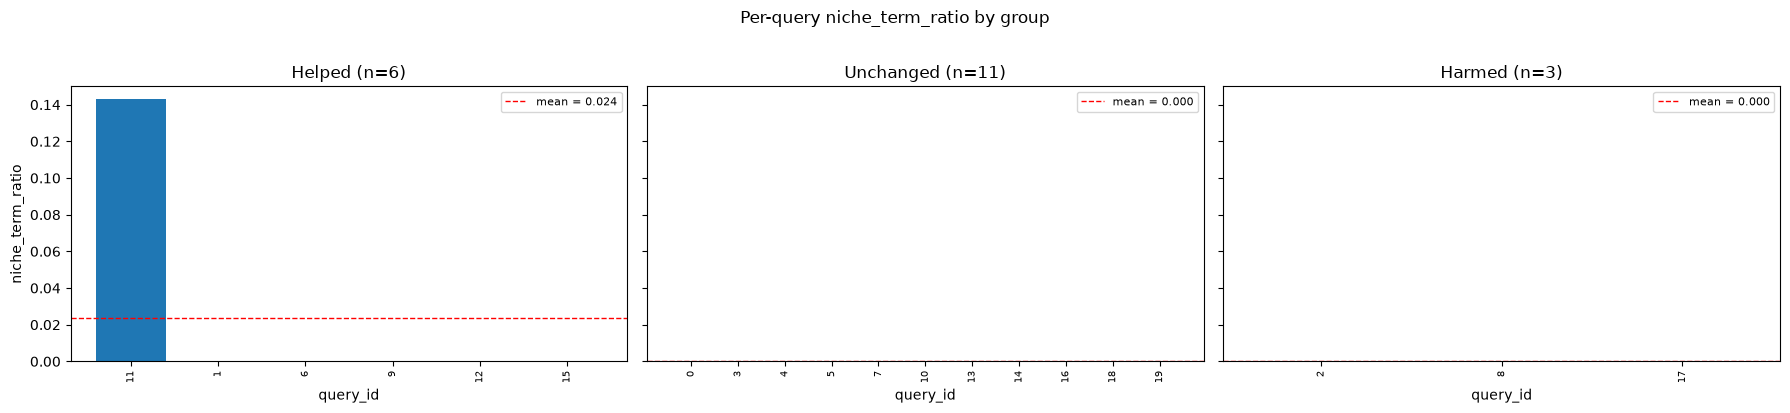

In [23]:
# -----------------------------------------------------------------------------
# CELL 8 (plots): Per-query metric plots per group
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt

GROUPS = [("Helped", helped), ("Unchanged", unchanged), ("Harmed", harmed)]
LABEL_THRESHOLD = 40  # above this many queries, x tick labels are hidden


def plot_metric_per_group(metric: str, groups=GROUPS, sort_by_value: bool = True):
    """One figure per metric: one subplot per group,
    query_id on the x-axis, metric value on the y-axis."""
    fig, axes = plt.subplots(1, len(groups), figsize=(6 * len(groups), 4), sharey=True)
    if len(groups) == 1:
        axes = [axes]

    for ax, (name, gdf) in zip(axes, groups):
        if gdf.empty:
            ax.set_title(f"{name}: no queries")
            continue

        # fallback if query_id is the index rather than a column
        if "query_id" not in gdf.columns:
            gdf = gdf.reset_index().rename(columns={gdf.index.name or "index": "query_id"})

        df = gdf[["query_id", metric]].copy()
        df[metric] = df[metric].astype(float)
        df = df.sort_values(metric, ascending=False) if sort_by_value else df.sort_values("query_id")

        x = range(len(df))
        mean_val = df[metric].mean()
        ax.bar(x, df[metric], width=0.8)
        ax.axhline(mean_val, color="red", linestyle="--", linewidth=1,
                   label=f"mean = {mean_val:.3f}")
        ax.set_title(f"{name} (n={len(df)})")
        ax.set_xlabel("query_id")
        ax.legend(fontsize=8)

        if len(df) <= LABEL_THRESHOLD:
            ax.set_xticks(list(x))
            ax.set_xticklabels(df["query_id"], rotation=90, fontsize=7)
        else:
            ax.set_xticks([])

    axes[0].set_ylabel(metric)
    fig.suptitle(f"Per-query {metric} by group", y=1.02)
    fig.tight_layout()
    plt.show()


# --- usage -------------------------------------------------------------------
# single metric of your choice:
plot_metric_per_group("niche_term_ratio")

# or loop over everything (one figure per metric):
# for metric in stats_cols:
#     plot_metric_per_group(metric)

## Per-query details and CSV export

In [ ]:
# -----------------------------------------------------------------------------
# CELL 9: Show per-query table and save results
# -----------------------------------------------------------------------------
display_cols = [
    "qid", "query", "base_ndcg", "rerank_ndcg",
    "delta_ndcg", "rel_top10", "rel_top50", "first_rel_rank",
    "coverage", "mean_df", "df_cv", "niche_term_ratio"
]
display(df[display_cols].style.format({"base_ndcg": "{:.4f}", "rerank_ndcg": "{:.4f}", "delta_ndcg": "{:+.4f}"}))

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved per-query CSV to: {OUTPUT_CSV}")